In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df=pd.read_csv("/content/Raw_data.csv")


In [ ]:
df.shape

(50000, 4)

In [ ]:
df.size

200000

In [ ]:
df.dtypes

,0
case_id,int64
activity,object
timestamp,object
resource,object


In [ ]:
df['timestamp']=pd.to_datetime(df['timestamp'], format="%d-%m-%Y %H:%M")

In [ ]:
df.dtypes

,0
case_id,int64
activity,object
timestamp,datetime64[ns]
resource,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   case_id    50000 non-null  int64         
 1   activity   50000 non-null  object        
 2   timestamp  50000 non-null  datetime64[ns]
 3   resource   50000 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 1.5+ MB


In [ ]:
df.isnull().sum()

,0
case_id,0
activity,0
timestamp,0
resource,0


In [ ]:
df = df.rename(columns={
'case_id': 'case:concept:name',
'activity': 'concept:name',
'timestamp': 'time:timestamp'
})


In [ ]:
df=df.sort_values(['case:concept:name','time:timestamp'])

In [ ]:
!pip install pm4py
import pm4py
log = pm4py.format_dataframe(
df,
case_id='case:concept:name',
activity_key='concept:name',
timestamp_key='time:timestamp'
)
log = pm4py.convert_to_event_log(log)
print("Number of cases:", len(log))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 26.0 MB/s eta 0:00:00
Number of cases: 5000


In [ ]:
print("Total events:", len(df))
print("Unique cases:", df['case:concept:name'].nunique())
print("Unique activities:", df['concept:name'].nunique())

Total events: 50000
Unique cases: 5000
Unique activities: 15


In [ ]:
print("Start:", df['time:timestamp'].min())
print("End:", df['time:timestamp'].max())

Start: 2024-01-01 08:16:00
End: 2024-01-15 11:47:00


In [ ]:
from pm4py.statistics.traces.generic.log import case_statistics
variants = case_statistics.get_variant_statistics(log)
print("Total Variants:", len(variants))


Total Variants: 12


In [ ]:
variants

[{'variant': ('Order_Placed',
   'Order_Validated',
   'Payment_Processed',
   'Inventory_Checked',
   'Warehouse_C',
   'Packed',
   'Order_Processed',
   'Route_A',
   'Out_for_Delivery',
   'Delivered'),
  'count': 853},
 {'variant': ('Order_Placed',
   'Order_Validated',
   'Payment_Processed',
   'Inventory_Checked',
   'Warehouse_C',
   'Packed',
   'Order_Processed',
   'Route_B',
   'Out_for_Delivery',
   'Delivered'),
  'count': 705},
 {'variant': ('Order_Placed',
   'Order_Validated',
   'Payment_Processed',
   'Inventory_Checked',
   'Warehouse_C',
   'Packed',
   'Order_Processed',
   'Route_C',
   'Out_for_Delivery',
   'Delivered'),
  'count': 575},
 {'variant': ('Order_Placed',
   'Order_Validated',
   'Payment_Processed',
   'Inventory_Checked',
   'Warehouse_A',
   'Packed',
   'Order_Processed',
   'Route_A',
   'Out_for_Delivery',
   'Delivered'),
  'count': 570},
 {'variant': ('Order_Placed',
   'Order_Validated',
   'Payment_Processed',
   'Inventory_Checked',
   '

In [ ]:
variants = sorted(variants, key=lambda x: x['count'], reverse=True)
for v in variants[:5]:
    print("Variant:", v['variant'])
    print("Frequency:", v['count'])
    print()

Variant: ('Order_Placed', 'Order_Validated', 'Payment_Processed', 'Inventory_Checked', 'Warehouse_C', 'Packed', 'Order_Processed', 'Route_A', 'Out_for_Delivery', 'Delivered')
Frequency: 853

Variant: ('Order_Placed', 'Order_Validated', 'Payment_Processed', 'Inventory_Checked', 'Warehouse_C', 'Packed', 'Order_Processed', 'Route_B', 'Out_for_Delivery', 'Delivered')
Frequency: 705

Variant: ('Order_Placed', 'Order_Validated', 'Payment_Processed', 'Inventory_Checked', 'Warehouse_C', 'Packed', 'Order_Processed', 'Route_C', 'Out_for_Delivery', 'Delivered')
Frequency: 575

Variant: ('Order_Placed', 'Order_Validated', 'Payment_Processed', 'Inventory_Checked', 'Warehouse_A', 'Packed', 'Order_Processed', 'Route_A', 'Out_for_Delivery', 'Delivered')
Frequency: 570

Variant: ('Order_Placed', 'Order_Validated', 'Payment_Processed', 'Inventory_Checked', 'Warehouse_B', 'Packed', 'Order_Processed', 'Route_A', 'Out_for_Delivery', 'Delivered')
Frequency: 451



In [ ]:
num_cases = len(log)
num_variants = len(variants)
VCI = num_variants / num_cases
print("Variant Complexity Index:", VCI)

Variant Complexity Index: 0.0024


In [ ]:
durations=case_statistics.get_all_case_durations(log)
print("AVerage Lead Time",sum(durations)/len(durations) )
print("Max Lead Time",max(durations) )
print("Min Lead Time",min(durations) )

AVerage Lead Time 13968.804
Max Lead Time 29820.0
Min Lead Time 4860.0


In [ ]:
avg_hours = (sum(durations)/len(durations)) / 3600
print("Average Lead Time (hours):", avg_hours)


Average Lead Time (hours): 3.8802233333333334


In [ ]:
p95 = np.percentile(durations, 95)
print("95th Percentile Lead Time (hours):", p95/3600)

95th Percentile Lead Time (hours): 5.933333333333334


In [ ]:
start = df['time:timestamp'].min()
end = df['time:timestamp'].max()
time_window = (end - start).total_seconds()
arrival_rate = len(log) / time_window
print("Arrival Rate (cases/sec):", arrival_rate)
print("Arrival Rate (cases/hour):", arrival_rate * 3600)

Arrival Rate (cases/sec): 0.004090782648536318
Arrival Rate (cases/hour): 14.726817534730744


In [ ]:
from pm4py.algo.discovery.dfg import algorithm as dfg_discovery
# Discover DFG (frequency-based)
dfg = dfg_discovery.apply(log)
print("Number of transitions:", len(dfg))

Number of transitions: 19


In [ ]:
sorted_edges = sorted(dfg.items(), key=lambda x: x[1], reverse=True)
print("T Direct Transitions:")
for edge, freq in sorted_edges[:10]:
    print(f"{edge[0]} → {edge[1]} : {freq}")

T Direct Transitions:
Order_Placed → Order_Validated : 5000
Order_Validated → Payment_Processed : 5000
Payment_Processed → Inventory_Checked : 5000
Packed → Order_Processed : 5000
Out_for_Delivery → Delivered : 5000
Inventory_Checked → Warehouse_C : 2263
Warehouse_C → Packed : 2263
Order_Processed → Route_A : 1874
Route_A → Out_for_Delivery : 1874
Order_Processed → Route_B : 1504


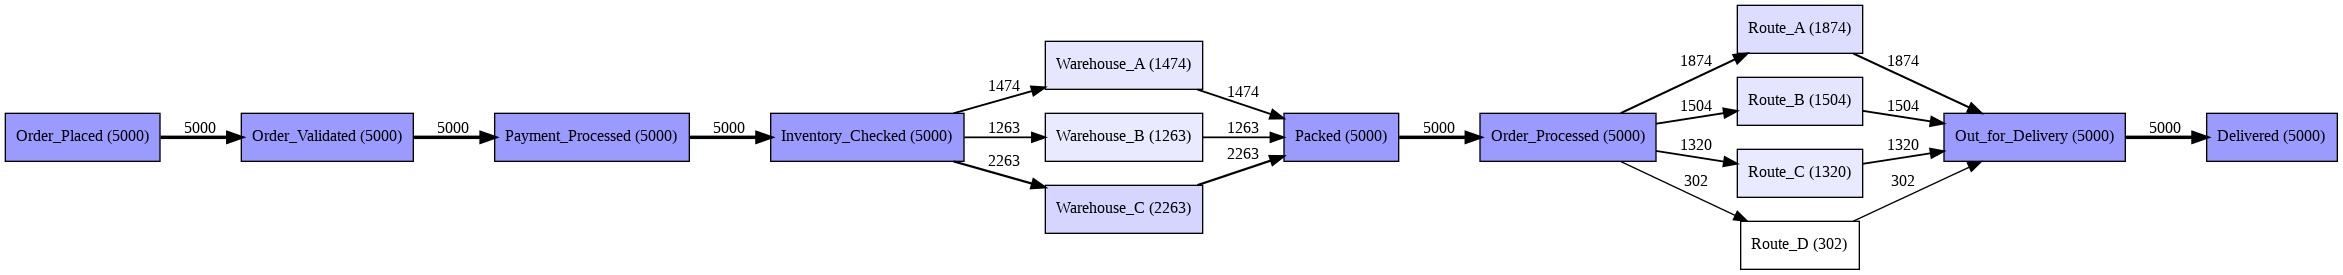

In [ ]:
from pm4py.visualization.dfg import visualizer as dfg_visualizer
gviz = dfg_visualizer.apply(dfg, log=log)
dfg_visualizer.view(gviz)

In [ ]:
from pm4py.statistics.start_activities.log import get as start_activities
from pm4py.statistics.end_activities.log import get as end_activities
start = start_activities.get_start_activities(log)
end = end_activities.get_end_activities(log)
print("Start Activities:", start)
print("End Activities:", end)


Start Activities: {'Order_Placed': 5000}
End Activities: {'Delivered': 5000}


In [ ]:
import collections
in_degree = collections.defaultdict(int)
out_degree = collections.defaultdict(int)
for (a, b), freq in dfg.items():
    out_degree[a] += freq
    in_degree[b] += freq
print("Activity Flow Balance:")
for act in set(list(in_degree.keys()) + list(out_degree.keys())):
    print(act, "IN:", in_degree[act], "OUT:", out_degree[act])

Activity Flow Balance:
Route_B IN: 1504 OUT: 1504
Inventory_Checked IN: 5000 OUT: 5000
Order_Processed IN: 5000 OUT: 5000
Warehouse_B IN: 1263 OUT: 1263
Route_C IN: 1320 OUT: 1320
Payment_Processed IN: 5000 OUT: 5000
Route_A IN: 1874 OUT: 1874
Route_D IN: 302 OUT: 302
Order_Placed IN: 0 OUT: 5000
Warehouse_C IN: 2263 OUT: 2263
Warehouse_A IN: 1474 OUT: 1474
Out_for_Delivery IN: 5000 OUT: 5000
Order_Validated IN: 5000 OUT: 5000
Delivered IN: 5000 OUT: 0
Packed IN: 5000 OUT: 5000


In [ ]:
from pm4py.algo.discovery.dfg import algorithm as dfg_discovery
from pm4py.visualization.dfg import visualizer as dfg_visualizer
# Discover performance DFG
dfg_perf = dfg_discovery.apply(
log,
variant=dfg_discovery.Variants.PERFORMANCE
)
print("Number of transitions:", len(dfg_perf))

Number of transitions: 19


In [ ]:
sorted_perf = sorted(dfg_perf.items(), key=lambda x: x[1], reverse=True)
print("Top 10 Slowest Transitions (seconds):")
for edge, avg_time in sorted_perf[:10]:
    print(f"{edge[0]} → {edge[1]} : {avg_time:.2f} sec")

Top 10 Slowest Transitions (seconds):
Order_Processed → Route_D : 6425.76 sec
Packed → Order_Processed : 3132.84 sec
Inventory_Checked → Warehouse_C : 3096.01 sec
Order_Processed → Route_C : 2355.45 sec
Route_B → Out_for_Delivery : 2115.40 sec
Route_C → Out_for_Delivery : 2111.91 sec
Route_D → Out_for_Delivery : 2092.25 sec
Route_A → Out_for_Delivery : 2042.18 sec
Inventory_Checked → Warehouse_B : 1779.52 sec
Warehouse_B → Packed : 1427.03 sec


In [ ]:
for edge, avg_time in sorted_perf[:10]:
   print(f"{edge[0]} → {edge[1]} : {avg_time/3600:.2f} hours")

Order_Processed → Route_D : 1.78 hours
Packed → Order_Processed : 0.87 hours
Inventory_Checked → Warehouse_C : 0.86 hours
Order_Processed → Route_C : 0.65 hours
Route_B → Out_for_Delivery : 0.59 hours
Route_C → Out_for_Delivery : 0.59 hours
Route_D → Out_for_Delivery : 0.58 hours
Route_A → Out_for_Delivery : 0.57 hours
Inventory_Checked → Warehouse_B : 0.49 hours
Warehouse_B → Packed : 0.40 hours


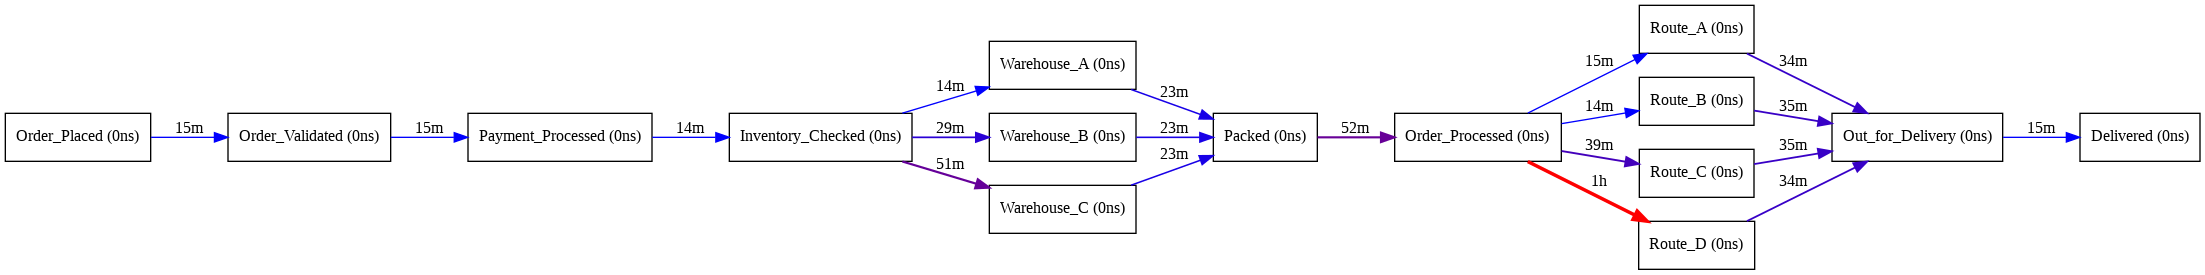

In [ ]:
gviz_perf = dfg_visualizer.apply(
dfg_perf,
log=log,
variant=dfg_visualizer.Variants.PERFORMANCE
)
dfg_visualizer.view(gviz_perf)

In [ ]:
import collections
activity_time = collections.defaultdict(float)
for (a, b), avg_time in dfg_perf.items():
    activity_time[a] += avg_time
    activity_time[b] += avg_time
sorted_nodes = sorted(activity_time.items(), key=lambda x: x[1], reverse=True)
print("Top Bottleneck Activities:")
for act, total_time in sorted_nodes[:5]:
    print(act, ":", total_time/3600, "hours cumulative")

Top Bottleneck Activities:
Order_Processed : 3.8091192528720397 hours cumulative
Out_for_Delivery : 2.573411345516961 hours cumulative
Route_D : 2.366114790286976 hours cumulative
Packed : 2.0491939710517757 hours cumulative
Inventory_Checked : 1.8529161138707089 hours cumulative


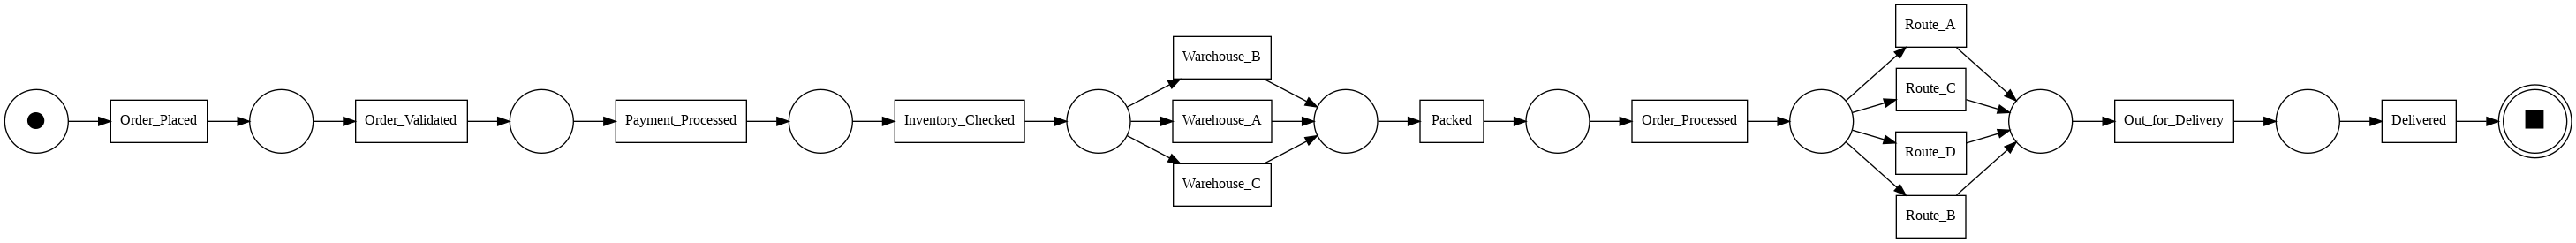

In [ ]:
from pm4py.algo.discovery.inductive import algorithm as inductive_miner
from pm4py.visualization.petri_net import visualizer as pn_visualizer
from pm4py.objects.conversion.process_tree import converter as pt_converter
# Discover Process Tree using the IM variant
process_tree = inductive_miner.apply(log, variant=inductive_miner.Variants.IM)
# Convert Process Tree to Petri Net, initial marking, and final marking
net, initial_marking, final_marking = pt_converter.apply(process_tree)
# Visualize
gviz = pn_visualizer.apply(net, initial_marking, final_marking)
pn_visualizer.view(gviz)

In [ ]:
print("Number of Places:", len(net.places))
print("Number of Transitions:", len(net.transitions))

Number of Places: 11
Number of Transitions: 15


In [ ]:
for t in net.transitions:
   print(t.label)

Order_Validated
Warehouse_B
Payment_Processed
Route_A
Out_for_Delivery
Order_Placed
Inventory_Checked
Warehouse_A
Warehouse_C
Packed
Order_Processed
Route_C
Route_D
Route_B
Delivered


In [ ]:
from pm4py.algo.conformance.tokenreplay import algorithm as token_replay
replayed = token_replay.apply(log, net, initial_marking, final_marking)
fitness = sum(x["trace_fitness"] for x in replayed) / len(replayed)
print("Average Fitness:", fitness)


replaying log with TBR, completed traces ::   0%|          | 0/12 [00:00<?, ?it/s]

Average Fitness: 1.0


In [ ]:
import networkx as nx
# Initialize an empty directed graph
G = nx.DiGraph()
# Add nodes to G for each unique activity
unique_activities = df['concept:name'].unique()
for activity in unique_activities:
  G.add_node(activity)
# Add edges to G from the dfg dictionary with frequency as weight
for (source, target), frequency in dfg.items():
  G.add_edge(source, target, weight=frequency)
# Create an execution_order list from unique activities
execution_order = list(unique_activities)
print("NetworkX graph G created with nodes and edges.")
print("Unique activities (execution_order) defined.")
print("Number of nodes in G:", G.number_of_nodes())
print("Number of edges in G:", G.number_of_edges())
print("Execution order:", execution_order)

NetworkX graph G created with nodes and edges.
Unique activities (execution_order) defined.
Number of nodes in G: 15
Number of edges in G: 19
Execution order: ['Order_Placed', 'Order_Validated', 'Payment_Processed', 'Inventory_Checked', 'Warehouse_A', 'Packed', 'Order_Processed', 'Route_A', 'Out_for_Delivery', 'Delivered', 'Warehouse_B', 'Route_B', 'Route_C', 'Warehouse_C', 'Route_D']


In [ ]:
for (source, target), avg_time in dfg_perf.items():
   if G.has_edge(source, target):
      G[source][target]['mean_time'] = avg_time
print("Edges in G updated with 'mean_time' attribute from dfg_perf.")
# Verify a few edges
for u, v, data in G.edges(data=True):
   if 'mean_time' in data:
      print(f"Edge ({u} -> {v}) has mean_time: {data['mean_time']:.2f} seconds")

Edges in G updated with 'mean_time' attribute from dfg_perf.
Edge (Order_Placed -> Order_Validated) has mean_time: 901.38 seconds
Edge (Order_Validated -> Payment_Processed) has mean_time: 901.98 seconds
Edge (Payment_Processed -> Inventory_Checked) has mean_time: 895.21 seconds
Edge (Inventory_Checked -> Warehouse_A) has mean_time: 899.76 seconds
Edge (Inventory_Checked -> Warehouse_B) has mean_time: 1779.52 seconds
Edge (Inventory_Checked -> Warehouse_C) has mean_time: 3096.01 seconds
Edge (Warehouse_A -> Packed) has mean_time: 1400.11 seconds
Edge (Packed -> Order_Processed) has mean_time: 3132.84 seconds
Edge (Order_Processed -> Route_A) has mean_time: 913.09 seconds
Edge (Order_Processed -> Route_B) has mean_time: 885.68 seconds
Edge (Order_Processed -> Route_D) has mean_time: 6425.76 seconds
Edge (Order_Processed -> Route_C) has mean_time: 2355.45 seconds
Edge (Route_A -> Out_for_Delivery) has mean_time: 2042.18 seconds
Edge (Out_for_Delivery -> Delivered) has mean_time: 902.54 s